In [2]:
import pandas as pd
import plotly.express as px
import numpy as np

play = pd.read_csv("Play Store Data.csv")
reviews = pd.read_csv("User Reviews.csv")

In [4]:
print(play.shape)
print(reviews.shape)

(10841, 13)
(64295, 5)


In [5]:
print(play.columns)
print()
print(reviews.columns)

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')


In [8]:
play = play.drop_duplicates(subset="App")
play.shape

(9660, 13)

In [12]:
play["Reviews"].dtype
play["Reviews"] = pd.to_numeric(
    play["Reviews"],
    errors="coerce"
)
play["Reviews"].dtype

dtype('float64')

In [16]:
play["Installs"] = (
    play["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)
play["Installs"].unique
play["Installs"] = pd.to_numeric(
    play["Installs"],
    errors="coerce"
)
play["Installs"].dtype
play["Installs"].head()

0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
Name: Installs, dtype: float64

In [20]:
play["Rating"] = pd.to_numeric(
    play["Rating"],
    errors="coerce"
)
play.isnull().sum()
play.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9660 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9660 non-null   object 
 1   Category        9660 non-null   object 
 2   Rating          8197 non-null   float64
 3   Reviews         9659 non-null   float64
 4   Size            9660 non-null   object 
 5   Installs        9659 non-null   float64
 6   Type            9659 non-null   object 
 7   Price           9660 non-null   object 
 8   Content Rating  9659 non-null   object 
 9   Genres          9660 non-null   object 
 10  Last Updated    9660 non-null   object 
 11  Current Ver     9652 non-null   object 
 12  Android Ver     9657 non-null   object 
dtypes: float64(3), object(10)
memory usage: 1.0+ MB


In [23]:
play["Reviews"] = play["Reviews"].astype("Int64")
play["Installs"] = play["Installs"].astype("Int64")
play = play.reset_index(drop=True)

In [52]:
play = play[
    ~play["Category"].str.startswith(
        ("A", "C", "G", "S"),
        na=False
    )
]
category_installs = (
    play.groupby("Category")["Installs"]
        .sum()
        .reset_index()
)
category_installs = (
    category_installs
    .sort_values(
        by="Installs",
        ascending=False
    )
    .head(5)
)
play = play[play["Category"] != "1.9"]
play = play.reset_index(drop=True)
category_installs.head()

,Category,Installs
21,TOOLS,8001771915
20,PRODUCTIVITY,5793091369
19,PHOTOGRAPHY,4649147655
7,FAMILY,4427941505
23,VIDEO_PLAYERS,3926902720


In [54]:
category_installs["Highlight"] = (
    category_installs["Installs"] > 1000000
)

category_installs["Country"] = [
    "India",
    "United States",
    "Brazil",
    "Germany",
    "Canada"
]
category_installs.head()

,Category,Installs,Highlight,Country
21,TOOLS,8001771915,True,India
20,PRODUCTIVITY,5793091369,True,United States
19,PHOTOGRAPHY,4649147655,True,Brazil
7,FAMILY,4427941505,True,Germany
23,VIDEO_PLAYERS,3926902720,True,Canada


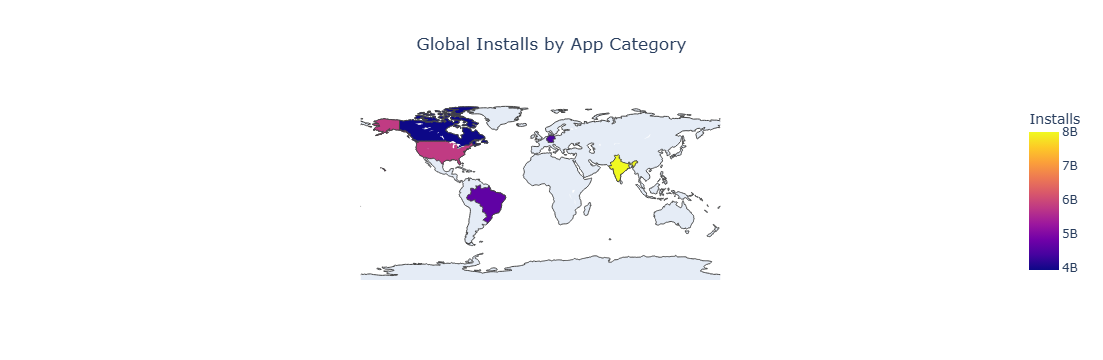

In [55]:
import plotly.express as px

fig = px.choropleth(
    category_installs,
    locations="Country",
    locationmode="country names",
    color="Installs",
    hover_name="Category",
    hover_data=["Installs"],
    title="Global Installs by App Category"
)
fig.update_layout(
    geo=dict(showframe=False),
    title_x=0.5
)
fig.show()

In [56]:
from datetime import datetime
import pytz

india = pytz.timezone("Asia/Kolkata")
now = datetime.now(india)

if 18 <= now.hour < 20:
    fig.show()
else:
    print(
        "Choropleth map is available only between "
        "6 PM and 8 PM IST."
    )

Choropleth map is available only between 6 PM and 8 PM IST.


In [57]:
fig.write_html(
    "choropleth_dashboard.html",
    include_plotlyjs="cdn"
)